In [2]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
# 2. Load Data
df = pd.read_csv(r"C:\Users\prati\OneDrive\Desktop\doctata\QVI_data.csv")  

In [4]:
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [6]:
df.isnull().sum()

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [7]:
df.columns

Index(['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='object')

In [8]:
# 3. Convert Date
try:
    df["DATE"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df["DATE"], unit="D")
except:
    df["DATE"] = pd.to_datetime(df["DATE"])


In [9]:
# 4. Create YearMonth
df["YEARMONTH"] = df["DATE"].dt.strftime("%Y%m").astype(int)

In [10]:
# 5. Monthly Metrics Per Store
monthly = df.groupby(["STORE_NBR","YEARMONTH"]).agg(
    TOT_SALES=("TOT_SALES","sum"),
    CUSTOMERS=("LYLTY_CARD_NBR","nunique"),
    TXNS=("TXN_ID","nunique")
).reset_index()

monthly["TXN_PER_CUST"] = monthly["TXNS"] / monthly["CUSTOMERS"]

print(monthly.head())


   STORE_NBR  YEARMONTH  TOT_SALES  CUSTOMERS  TXNS  TXN_PER_CUST
0          1     201807      206.9         49    52      1.061224
1          1     201808      176.1         42    43      1.023810
2          1     201809      278.8         59    62      1.050847
3          1     201810      188.1         44    45      1.022727
4          1     201811      192.6         46    47      1.021739


In [11]:
# 6. Trial Stores
trial_stores = [77, 86, 88]


In [12]:
# 7. Pre-Trial Period
pretrial = monthly[monthly["YEARMONTH"] < 201902]

In [13]:
# 8. Function to Find Best Control Store
def find_control_store(trial_store):
    
    trial_data = pretrial[pretrial["STORE_NBR"] == trial_store]
    candidate_scores = []

    for store in pretrial["STORE_NBR"].unique():
        
        if store in trial_stores:
            continue
            
        control = pretrial[pretrial["STORE_NBR"] == store]

        merged = pd.merge(
            trial_data,
            control,
            on="YEARMONTH",
            suffixes=("_trial","_control")
        )

        if len(merged) < 3:
            continue

        # Correlation of sales
        corr_sales = merged["TOT_SALES_trial"].corr(
            merged["TOT_SALES_control"]
        )

        # Correlation customers
        corr_cust = merged["CUSTOMERS_trial"].corr(
            merged["CUSTOMERS_control"]
        )

        score = (corr_sales + corr_cust) / 2

        candidate_scores.append([trial_store, store, score])

    result = pd.DataFrame(
        candidate_scores,
        columns=["Trial_Store","Control_Store","Score"]
    )

    return result.sort_values("Score", ascending=False).head(1)

In [14]:
# 9. Get Best Control Stores
control_77 = find_control_store(77)
control_86 = find_control_store(86)
control_88 = find_control_store(88)

print(control_77)
print(control_86)
print(control_88)


     Trial_Store  Control_Store     Score
221           77            233  0.947066
     Trial_Store  Control_Store     Score
146           86            155  0.910379
     Trial_Store  Control_Store     Score
169           88            178  0.835661


In [15]:
# 10. Selected Controls
control_map = {
    77: int(control_77["Control_Store"].values[0]),
    86: int(control_86["Control_Store"].values[0]),
    88: int(control_88["Control_Store"].values[0])
}

print(control_map)

{77: 233, 86: 155, 88: 178}


In [16]:
# 11. Trial Period
trial_period = monthly[
    (monthly["YEARMONTH"] >= 201902) &
    (monthly["YEARMONTH"] <= 201904)
]

In [17]:
# 12. Compare Trial vs Control

for trial in trial_stores:
    
    control = control_map[trial]

    trial_data = trial_period[
        trial_period["STORE_NBR"] == trial
    ]["TOT_SALES"]

    control_data = trial_period[
        trial_period["STORE_NBR"] == control
    ]["TOT_SALES"]

    stat, p = ttest_ind(trial_data, control_data)

    print("\n================================")
    print("Trial Store:", trial)
    print("Control Store:", control)
    print("p-value:", round(p,4))

    if p < 0.05:
        print("Significant Difference Found")
    else:
        print("No Significant Difference")



Trial Store: 77
Control Store: 233
p-value: 0.1031
No Significant Difference

Trial Store: 86
Control Store: 155
p-value: 0.2266
No Significant Difference

Trial Store: 88
Control Store: 178
p-value: 0.0008
Significant Difference Found


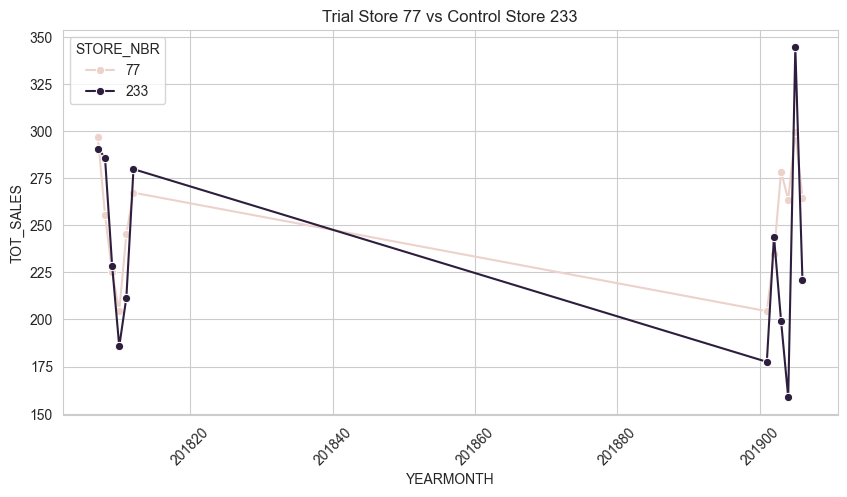

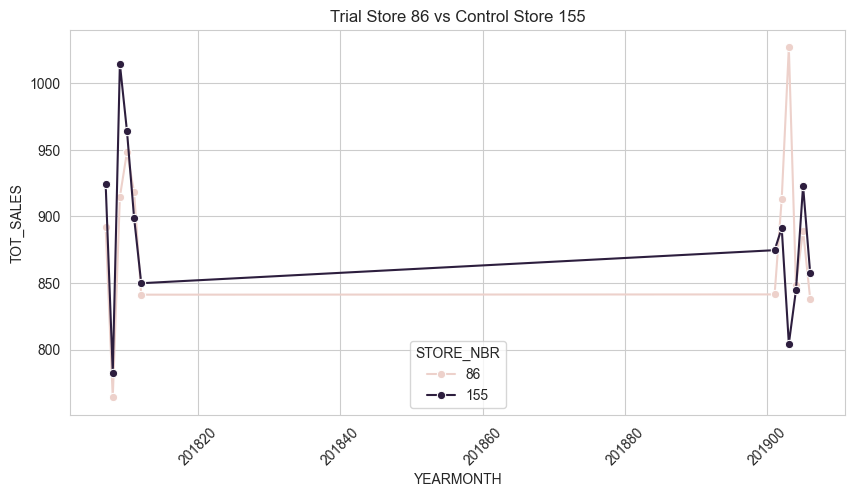

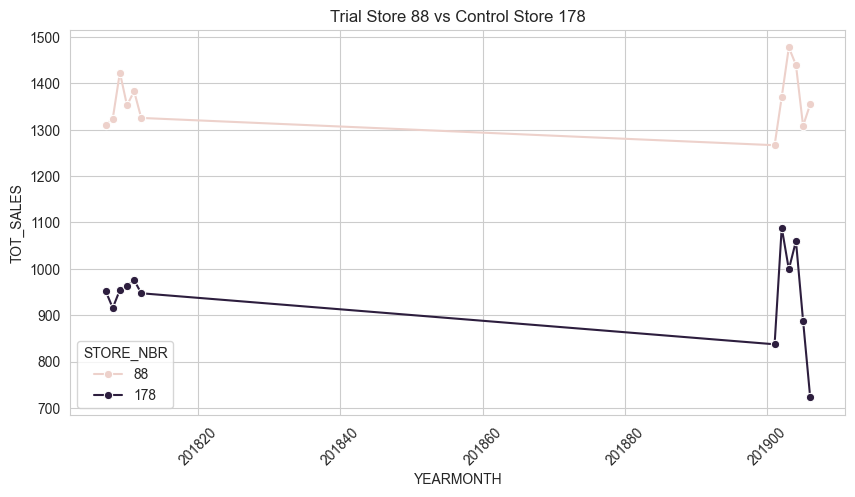

In [18]:
# 13. Sales Charts

for trial in trial_stores:
    
    control = control_map[trial]

    temp = monthly[
        monthly["STORE_NBR"].isin([trial, control])
    ]

    plt.figure(figsize=(10,5))
    
    sns.lineplot(
        data=temp,
        x="YEARMONTH",
        y="TOT_SALES",
        hue="STORE_NBR",
        marker="o"
    )

    plt.title(f"Trial Store {trial} vs Control Store {control}")
    plt.xticks(rotation=45)
    plt.show()

In [19]:
# 14. Customer Comparison

for trial in trial_stores:
    
    control = control_map[trial]

    temp = trial_period[
        trial_period["STORE_NBR"].isin([trial, control])
    ][["STORE_NBR","CUSTOMERS","TXN_PER_CUST"]]

    print("\nStore Comparison:", trial, "vs", control)
    print(temp)


Store Comparison: 77 vs 233
      STORE_NBR  CUSTOMERS  TXN_PER_CUST
887          77         45      1.000000
888          77         50      1.100000
889          77         47      1.021277
2706        233         45      1.044444
2707        233         40      1.025000
2708        233         30      1.066667

Store Comparison: 86 vs 155
      STORE_NBR  CUSTOMERS  TXN_PER_CUST
984          86        107      1.289720
985          86        115      1.217391
986          86        105      1.200000
1800        155         95      1.315789
1801        155         94      1.255319
1802        155         99      1.212121

Store Comparison: 88 vs 178
      STORE_NBR  CUSTOMERS  TXN_PER_CUST
1008         88        124      1.233871
1009         88        134      1.261194
1010         88        128      1.265625
2076        178        107      1.355140
2077        178        114      1.254386
2078        178        117      1.264957


In [20]:
# 15. Final Insights

print("\n======================================")
print("BUSINESS RECOMMENDATION")
print("======================================")
print("1. Stores with significant uplift performed well.")
print("2. If customer count increased -> better foot traffic.")
print("3. If txn/customer increased -> stronger loyalty.")
print("4. Recommend rollout only for successful trial stores.")
print("5. Investigate weak trial stores before expansion.")



BUSINESS RECOMMENDATION
1. Stores with significant uplift performed well.
2. If customer count increased -> better foot traffic.
3. If txn/customer increased -> stronger loyalty.
4. Recommend rollout only for successful trial stores.
5. Investigate weak trial stores before expansion.


In [21]:
# 16. Save Result

monthly.to_csv("Task2_Output.csv", index=False)

print("\nTask 2 Completed Successfully")


Task 2 Completed Successfully
